<a href="https://colab.research.google.com/github/JoaoIvo15/Regressao-Multipla-Energy-Efficiency/blob/main/notebooks/02_modelagem_MRLM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02 — Modelagem por Regressão Linear Múltipla

**Dataset:** Energy Efficiency
**Disciplina:** Modelagem Estatística


## Objetivo

Construir e avaliar modelos de **Regressão Linear Múltipla** para as variáveis resposta **Y1 (Heating Load)** e **Y2 (Cooling Load)**, utilizando como base os resultados obtidos na análise exploratória.

A etapa de modelagem contempla a especificação do modelo, estimação dos parâmetros, inferência estatística e investigação da multicolinearidade entre os preditores.


## Preparação do Ambiente

In [20]:
# Bibliotecas para modelagem e análise estatística

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Fonte do dataset no GitHub

DATA_URL = (
    "https://raw.githubusercontent.com/"
    "JoaoIvo15/Regressao-Multipla-Energy-Efficiency/"
    "main/data/raw/ENB2012_data.xlsx"
)

# Carregamento da base original

df = pd.read_excel(DATA_URL)

## 1. Preparação para a modelagem

A modelagem será realizada a partir da base original, preservando os dados utilizados na análise exploratória.

As variáveis **X1, X2, X3, X4, X5 e X7** serão inicialmente representadas quantitativamente. As variáveis **X6 (Orientation)** e **X8 (Glazing Area Distribution)**, por representarem categorias codificadas numericamente, serão convertidas em variáveis indicadoras.

A transformação será realizada em uma cópia da base, mantendo o objeto `df` inalterado.


In [21]:
# Cópia da base original

df_model = df.copy()

In [22]:
# Conversão de X6 e X8 em variáveis indicadoras

df_model = pd.get_dummies(
    df_model,
    columns=["X6", "X8"],
    drop_first=True,
    dtype=int
)

display(df_model.head())

,X1,X2,X3,X4,X5,X7,Y1,Y2,X6_3,X6_4,X6_5,X8_1,X8_2,X8_3,X8_4,X8_5
0,0.98,514.5,294.0,110.25,7.0,0.0,15.55,21.33,0,0,0,0,0,0,0,0
1,0.98,514.5,294.0,110.25,7.0,0.0,15.55,21.33,1,0,0,0,0,0,0,0
2,0.98,514.5,294.0,110.25,7.0,0.0,15.55,21.33,0,1,0,0,0,0,0,0
3,0.98,514.5,294.0,110.25,7.0,0.0,15.55,21.33,0,0,1,0,0,0,0,0
4,0.90,563.5,318.5,122.50,7.0,0.0,20.84,28.28,0,0,0,0,0,0,0,0


In [23]:
# Variáveis disponíveis na base de modelagem

df_model.columns.tolist()

['X1',
 'X2',
 'X3',
 'X4',
 'X5',
 'X7',
 'Y1',
 'Y2',
 'X6_3',
 'X6_4',
 'X6_5',
 'X8_1',
 'X8_2',
 'X8_3',
 'X8_4',
 'X8_5']

## 2. Dependência Linear entre os Preditores

Antes da estimação dos modelos de Regressão Linear Múltipla, é necessário verificar se as variáveis explicativas fornecem informações independentes entre si. Essa análise é particularmente importante porque a presença de dependência linear entre os preditores pode comprometer a identificação dos coeficientes do modelo.

Na análise exploratória realizada no Notebook 01, foram observadas associações muito fortes entre algumas variáveis geométricas do conjunto de dados. Entre elas, destacou-se uma relação exata entre X2, X3 e X4. Diferentemente de uma correlação apenas elevada, essa relação representa uma dependência linear determinística existente em todas as observações da base.

Nesta seção, essa dependência será demonstrada algebricamente e computacionalmente, e serão discutidas suas consequências para a estimação por Mínimos Quadrados Ordinários.


### 2.1 Relação determinística entre X2, X3 e X4

Durante a análise das variáveis explicativas, foi identificada a seguinte relação:

$$
X_2 = X_3 + 2X_4
$$

Essa igualdade indica que o valor de X2 pode ser determinado exatamente a partir de X3 e X4. Portanto, uma das três variáveis não acrescenta uma nova dimensão de informação quando as outras duas já estão presentes.

Essa característica é diferente de uma associação linear forte, na qual os valores das variáveis apenas tendem a acompanhar uma determinada relação. Neste caso, a relação é exata: não há erro ou variação residual entre os dois lados da igualdade.

Como consequência, as colunas correspondentes a X2, X3 e X4 não são linearmente independentes.


In [24]:
relation_error = df["X2"] - df["X3"] - 2 * df["X4"]

print("Maior erro absoluto:")
print(relation_error.abs().max())

Maior erro absoluto:
0.0


In [25]:
relation_holds = np.allclose(
    df["X2"],
    df["X3"] + 2 * df["X4"]
)

print("X2 = X3 + 2*X4 válida para toda a base:", relation_holds)

X2 = X3 + 2*X4 válida para toda a base: True


### 2.2 Definição formal de dependência linear

Um conjunto de variáveis é linearmente dependente quando existe uma combinação linear não trivial entre elas que resulta na variável nula.

A relação encontrada pode ser reescrita como:

$$
X_2 - X_3 - 2X_4 = 0
$$

Assim, existe uma combinação linear dos três preditores que é identicamente igual a zero em todas as observações.

Em termos de um vetor de coeficientes,

$$
\begin{bmatrix}
1\\
-1\\
-2
\end{bmatrix},
$$

tem-se:

$$
[X_2\;\;X_3\;\;X_4]
\begin{bmatrix}
1\\
-1\\
-2
\end{bmatrix}
=
0.
$$

Como esse vetor de coeficientes não é o vetor nulo, a combinação caracteriza uma dependência linear exata entre as variáveis.


In [26]:
X_geometry = df[["X2", "X3", "X4"]].to_numpy()

dependence_vector = np.array([1, -1, -2])

dependence_result = X_geometry @ dependence_vector

print("Maior valor absoluto da combinação linear:")
print(np.abs(dependence_result).max())

Maior valor absoluto da combinação linear:
0.0


### 2.3 Demonstração pelo posto da matriz

Outra forma de verificar a dependência linear é analisar o posto da matriz formada pelas variáveis X2, X3 e X4.

Se as três colunas fossem linearmente independentes, o posto da matriz seria igual a 3. Entretanto, como uma delas pode ser obtida exatamente a partir das outras duas, espera-se um posto igual a 2.


In [27]:
X_geometry = df[["X2", "X3", "X4"]].to_numpy()

rank_geometry = np.linalg.matrix_rank(X_geometry)

print("Número de colunas:", X_geometry.shape[1])
print("Posto da matriz [X2, X3, X4]:", rank_geometry)

Número de colunas: 3
Posto da matriz [X2, X3, X4]: 2


O posto da matriz é igual a 2, enquanto existem 3 colunas. Portanto, as colunas não são linearmente independentes, confirmando computacionalmente a dependência identificada anteriormente.

O resultado não decorre de arredondamentos ou de uma aproximação numérica entre as variáveis, mas da relação determinística já demonstrada:

$$
X_2-X_3-2X_4=0.
$$


### 2.4 Consequência para a estimação do MRLM

Considere inicialmente um modelo que utilize simultaneamente X2, X3 e X4:

$$
Y_i = \beta_0+\beta_2X_{2i}+\beta_3X_{3i}+\beta_4X_{4i}+\varepsilon_i.
$$

Em forma matricial:

$$
\mathbf{Y}=\mathbf{X}\boldsymbol{\beta}+\boldsymbol{\varepsilon},
$$

em que a matriz de projeto contém as colunas correspondentes ao intercepto, X2, X3 e X4:

$$
\mathbf{X}
=
\begin{bmatrix}
1 & X_2 & X_3 & X_4
\end{bmatrix}.
$$

Como existe a relação

$$
X_2-X_3-2X_4=0,
$$

as quatro colunas da matriz de projeto não são linearmente independentes. Consequentemente, a matriz não possui posto completo.


In [28]:
X_geometry_intercept = np.column_stack([
    np.ones(len(df)),
    df["X2"].to_numpy(),
    df["X3"].to_numpy(),
    df["X4"].to_numpy()
])

rank_design = np.linalg.matrix_rank(X_geometry_intercept)

print("Número de colunas da matriz de projeto:", X_geometry_intercept.shape[1])
print("Posto da matriz de projeto:", rank_design)

Número de colunas da matriz de projeto: 4
Posto da matriz de projeto: 3


A matriz de projeto possui quatro colunas, mas seu posto é igual a 3. Portanto, não possui posto completo.

A inclusão do intercepto não é responsável pela dependência. A relação linear já existe entre as colunas X2, X3 e X4 e permanece presente quando a coluna de 1's é adicionada.


Na estimação por Mínimos Quadrados Ordinários, o estimador dos coeficientes é usualmente escrito como

$$
\hat{\boldsymbol{\beta}}
=
(\mathbf{X}^{T}\mathbf{X})^{-1}
\mathbf{X}^{T}\mathbf{Y}.
$$

Para que essa expressão produza uma solução única por meio da inversa, a matriz de projeto deve possuir posto completo. Quando existe dependência linear exata entre suas colunas, $\mathbf{X}^{T}\mathbf{X}$ é singular e não possui inversa ordinária.

Assim, os coeficientes associados a X2, X3 e X4 não podem ser identificados individualmente de forma única quando as três variáveis são incluídas simultaneamente no modelo.


A consequência também pode ser observada diretamente substituindo a relação

$$
X_2=X_3+2X_4
$$

no modelo:

$$
Y
=
\beta_0+\beta_2X_2+\beta_3X_3+\beta_4X_4+\varepsilon.
$$

Substituindo X2:

$$
Y
=
\beta_0+\beta_2(X_3+2X_4)+\beta_3X_3+\beta_4X_4+\varepsilon.
$$

Agrupando os termos:

$$
Y
=
\beta_0
+
(\beta_2+\beta_3)X_3
+
(2\beta_2+\beta_4)X_4
+
\varepsilon.
$$

Portanto, os dados identificam apenas as combinações

$$
\beta_2+\beta_3
$$

e

$$
2\beta_2+\beta_4,
$$

e não os três coeficientes $\beta_2,\beta_3,\beta_4$ individualmente.

Esse resultado fornece uma interpretação direta para a perda de identificabilidade: diferentes combinações dos coeficientes podem produzir exatamente o mesmo valor ajustado para todas as observações.


### 2.5 Dependência perfeita e multicolinearidade forte

É importante distinguir a dependência linear exata identificada entre X2, X3 e X4 de uma situação de multicolinearidade elevada, mas não perfeita.

Na multicolinearidade forte, os preditores apresentam associação linear elevada, porém ainda existe informação suficiente para que a matriz de projeto mantenha posto completo. Nesse caso, os coeficientes podem ser estimados, embora suas estimativas possam apresentar maior variabilidade, erros-padrão elevados e maior sensibilidade às alterações nos dados ou na especificação do modelo.

Na dependência linear perfeita, por outro lado, existe uma combinação linear exata entre os preditores. A matriz de projeto deixa de possuir posto completo e os coeficientes individuais das variáveis envolvidas não são identificáveis de forma única.

Portanto, a relação

$$
X_2=X_3+2X_4
$$

não representa apenas uma correlação elevada: trata-se de uma dependência linear determinística.


### 2.6 Implicação para a especificação do modelo

A análise realizada mostrou que X2, X3 e X4 não podem ser incluídas simultaneamente como preditores independentes em um modelo de Regressão Linear Múltipla, pois apresentam dependência linear perfeita.

Consequentemente, a especificação dos modelos deverá considerar essa estrutura. Será necessário definir uma representação do conjunto de variáveis geométricas que preserve a informação relevante da base sem introduzir dependência linear perfeita na matriz de projeto.

A escolha das variáveis que permanecerão na especificação não será feita apenas com base na magnitude das correlações observadas. Também serão considerados o significado das variáveis, a interpretação dos coeficientes e o objetivo do modelo.

Com essa questão identificada, a próxima etapa consiste em definir formalmente o conjunto de preditores e a representação das variáveis categóricas para a estimação dos modelos.


### 2.7 Definição do conjunto inicial de preditores

A dependência linear perfeita identificada entre X2, X3 e X4 impede que essas três variáveis sejam utilizadas simultaneamente como preditores independentes em um mesmo modelo de Regressão Linear Múltipla.

Para a especificação inicial, optou-se por manter X3 (Wall Area) e X4 (Roof Area), excluindo X2 (Surface Area). Essa escolha permite representar separadamente as duas características geométricas que determinam X2 por meio da relação

$$
X_2 = X_3 + 2X_4.
$$

A exclusão de X2, portanto, não representa uma conclusão de que essa variável seja irrelevante para as variáveis resposta. Trata-se de uma decisão de especificação necessária para evitar dependência linear perfeita entre os preditores.

Dessa forma, o conjunto inicial de variáveis explicativas é composto por X1, X3, X4, X5, X6, X7 e X8. As variáveis X6 e X8 são representadas no modelo por variáveis indicadoras, conforme definido na etapa de preparação dos dados.

Esse conjunto será utilizado como referência para a investigação da multicolinearidade e para a construção dos modelos iniciais.


In [29]:
predictors_initial = [
    "X1",
    "X3",
    "X4",
    "X5",
    "X6",
    "X7",
    "X8"
]

print("Preditores do conjunto inicial:")
print(predictors_initial)

Preditores do conjunto inicial:
['X1', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8']


## 3. Diagnóstico de Multicolinearidade

A identificação da dependência linear perfeita entre X2, X3 e X4 não elimina a possibilidade de existência de outras relações lineares fortes entre os preditores. Embora essas relações não necessariamente impeçam a estimação do modelo, podem aumentar a variabilidade das estimativas dos coeficientes e dificultar sua interpretação.

Nesta etapa, investiga-se a presença de multicolinearidade entre as variáveis explicativas que compõem o conjunto inicial de preditores. Inicialmente, são analisadas as correlações entre as variáveis quantitativas.


In [30]:
quantitative_predictors_initial = [
    "X1",
    "X3",
    "X4",
    "X5",
    "X7"
]

correlation_matrix = df_model[
    quantitative_predictors_initial
].corr()

correlation_matrix

,X1,X3,X4,X5,X7
X1,1.000000e+00,-2.037817e-01,-8.688234e-01,8.277473e-01,-2.960552e-15
X3,-2.037817e-01,1.000000e+00,-2.923165e-01,2.809757e-01,-8.567455e-17
X4,-8.688234e-01,-2.923165e-01,1.000000e+00,-9.725122e-01,-1.759011e-15
X5,8.277473e-01,2.809757e-01,-9.725122e-01,1.000000e+00,1.489134e-17
X7,-2.960552e-15,-8.567455e-17,-1.759011e-15,1.489134e-17,1.000000e+00


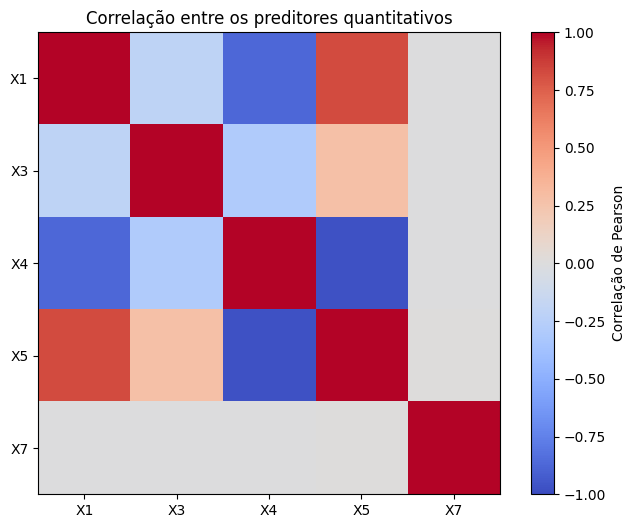

In [31]:
plt.figure(figsize=(8, 6))

plt.imshow(
    correlation_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Correlação de Pearson")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlação entre os preditores quantitativos")

plt.show()

### 3.1 Variance Inflation Factor (VIF)

O Variance Inflation Factor (VIF) é utilizado para avaliar o grau de multicolinearidade associado a cada variável explicativa. Para um determinado preditor $X_j$, define-se

$$
VIF_j = \frac{1}{1-R_j^2},
$$

em que $R_j^2$ é o coeficiente de determinação obtido ao ajustar $X_j$ como variável resposta em função dos demais preditores.

Assim, o VIF mede quanto a variância da estimativa do coeficiente associado a $X_j$ é inflacionada pela relação linear entre esse preditor e os demais.

Quando $R_j^2$ é próximo de 1, grande parte da variação de $X_j$ pode ser explicada pelos outros preditores, fazendo com que o VIF assuma valores elevados.

É importante destacar que o VIF é utilizado para investigar multicolinearidade, e não para detectar exclusivamente relações determinísticas como a identificada anteriormente entre X2, X3 e X4.


In [32]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [33]:
model_predictors = [
    "X1",
    "X3",
    "X4",
    "X5",
    "X7",
    "X6_3",
    "X6_4",
    "X6_5",
    "X8_1",
    "X8_2",
    "X8_3",
    "X8_4",
    "X8_5"
]

X_vif = df_model[model_predictors]

X_vif = sm.add_constant(X_vif)

vif_table = pd.DataFrame({
    "Variável": X_vif.columns,
    "VIF": [
        variance_inflation_factor(
            X_vif.values,
            i
        )
        for i in range(X_vif.shape[1])
    ]
})

vif_table

,Variável,VIF
0,const,1.000000
1,X1,105.524054
2,X3,27.662740
3,X4,211.938336
4,X5,31.205474
5,X7,1.260417
6,X6_3,1.500000
7,X6_4,1.500000
8,X6_5,1.500000
9,X8_1,3.927083


### 3.2 Interpretação dos resultados

O diagnóstico de multicolinearidade revelou diferenças importantes entre os preditores. X1, X3, X4 e X5 apresentaram valores de VIF elevados, com destaque para X4, cujo VIF foi aproximadamente 211,94. X1, X3 e X5 também apresentaram valores elevados, de aproximadamente 105,52, 27,66 e 31,21, respectivamente.

Esses resultados indicam forte redundância linear entre as variáveis geométricas. Em particular, para X4, o valor do VIF implica um $R_j^2$ de aproximadamente 0,995, indicando que cerca de 99,5% da variabilidade de X4 pode ser explicada linearmente pelos demais preditores considerados no diagnóstico.

Os resultados são consistentes com as associações observadas anteriormente entre as características geométricas dos edifícios. Entretanto, diferentemente da relação exata $X_2=X_3+2X_4$, a multicolinearidade observada entre X1, X3, X4 e X5 não representa dependência linear perfeita. Assim, os coeficientes continuam sendo estimáveis, mas suas estimativas podem apresentar elevada variabilidade e menor precisão.

Por outro lado, X7 apresentou VIF próximo de 1, indicando baixa relação linear com os demais preditores. As variáveis indicadoras associadas a X6 também apresentaram VIF baixo, enquanto as dummies de X8 apresentaram valores próximos de 3,93, indicando uma associação moderada, mas substancialmente inferior à observada entre as variáveis geométricas.

Dessa forma, o principal problema de multicolinearidade remanescente concentra-se no conjunto X1, X3, X4 e X5. Essa característica deverá ser considerada na construção e comparação dos modelos, mas não será utilizada isoladamente como critério automático para exclusão de variáveis.


## 4. Construção e comparação dos modelos

Após a análise da estrutura de dependência entre os preditores e do diagnóstico preliminar de multicolinearidade, inicia-se a construção dos modelos de Regressão Linear Múltipla para as variáveis resposta Y1 (Heating Load) e Y2 (Cooling Load).

A estratégia adotada não consiste na definição antecipada de um único modelo final. Em vez disso, serão consideradas diferentes especificações do conjunto de variáveis explicativas, permitindo avaliar como a inclusão ou exclusão de determinados preditores afeta o ajuste, a precisão das estimativas e a complexidade do modelo.

A comparação será realizada considerando medidas de ajuste e parcimônia, como $R^2$, $R^2$ ajustado, AIC e BIC, além da análise da significância dos coeficientes, do teste F global e dos indicadores de multicolinearidade.

Particular atenção será dada às variáveis geométricas X2, X3 e X4. Como foi demonstrada uma dependência linear perfeita entre as três, não serão consideradas especificações que contenham simultaneamente X2, X3 e X4.

Além dos modelos obtidos por procedimentos de seleção de variáveis, serão analisadas especificações alternativas para a representação das características geométricas, permitindo avaliar o efeito da escolha dos preditores sobre os resultados inferenciais.
